--- PHẦN 1 ---
2     2.29
92    2.33
25    2.40
44    2.42
97    2.57
Name: DH1, dtype: float64
             count    sum      mean median   min   max       std
               DH1    DH1       DH1    DH1   DH1   DH1       DH1
KT KV  DT                                                       
A  1   Kinh      8  49.08  6.135000  6.125  2.75  9.33  2.842318
   2   Khmer     1   5.62  5.620000  5.620  5.62  5.62       NaN
       Kinh      3  20.96  6.986667  6.260  5.72  8.98  1.747265
       Tày       1   8.47  8.470000  8.470  8.47  8.47       NaN
   2NT Kinh      6  32.94  5.490000  4.945  2.33  8.50  2.218774
   3   Khmer     1   7.29  7.290000  7.290  7.29  7.29       NaN
       Kinh      3  17.59  5.863333  6.150  5.27  6.17  0.513939
       Tày       1   3.79  3.790000  3.790  3.79  3.79       NaN
A1 1   Kinh      2  11.13  5.565000  5.565  4.61  6.52  1.350574
   2   Kinh      2  11.54  5.770000  5.770  2.85  8.69  4.129504
   2NT Kinh      4  20.81  5.202500  4.550  2.69  9.02  2.7

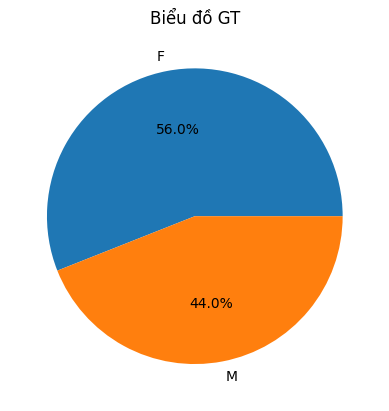

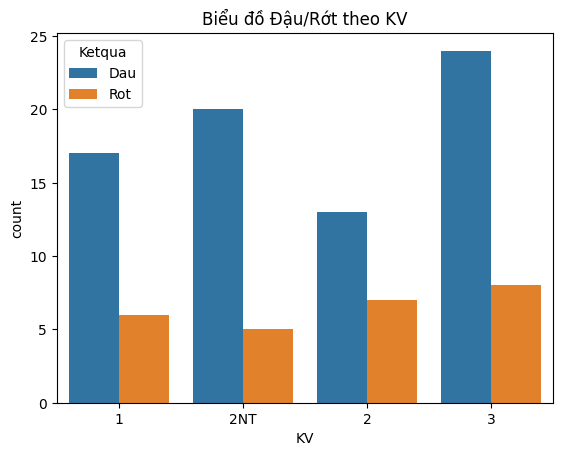


--- PHẦN 4 ---


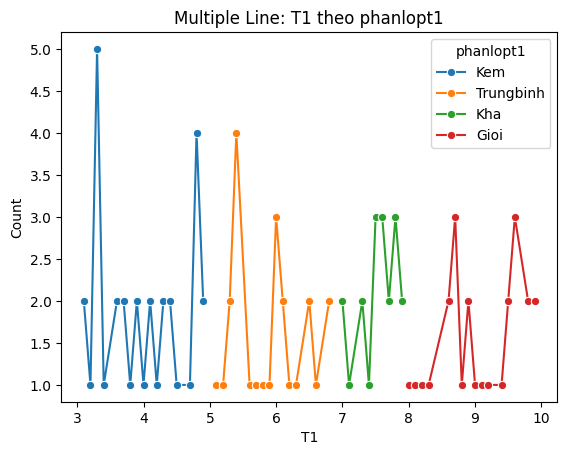


--- PHẦN 5 ---


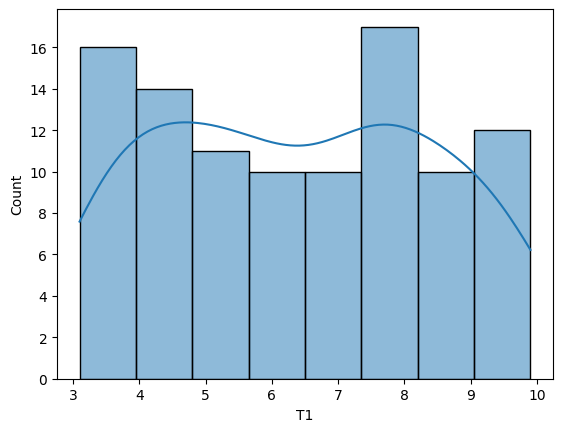

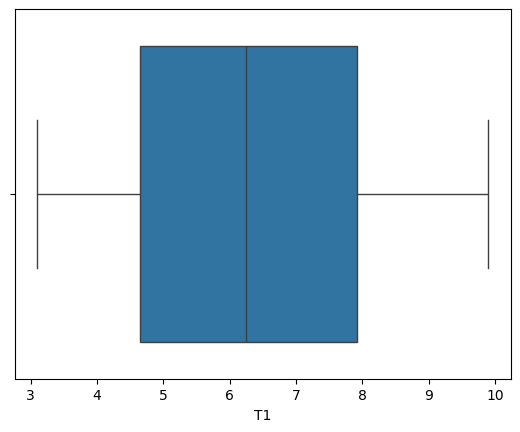

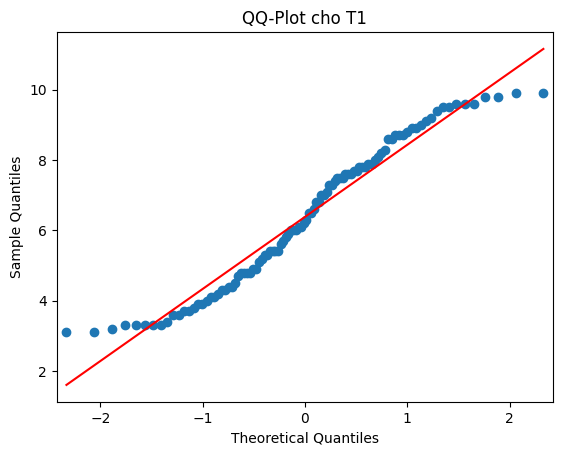

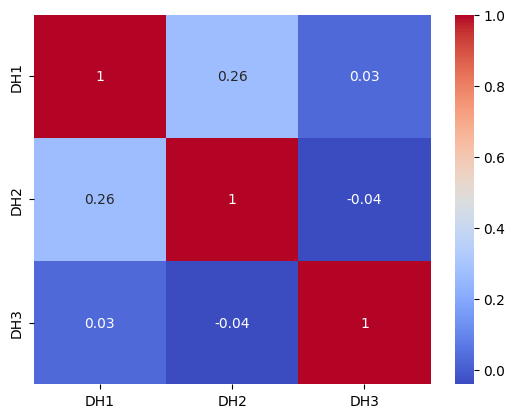

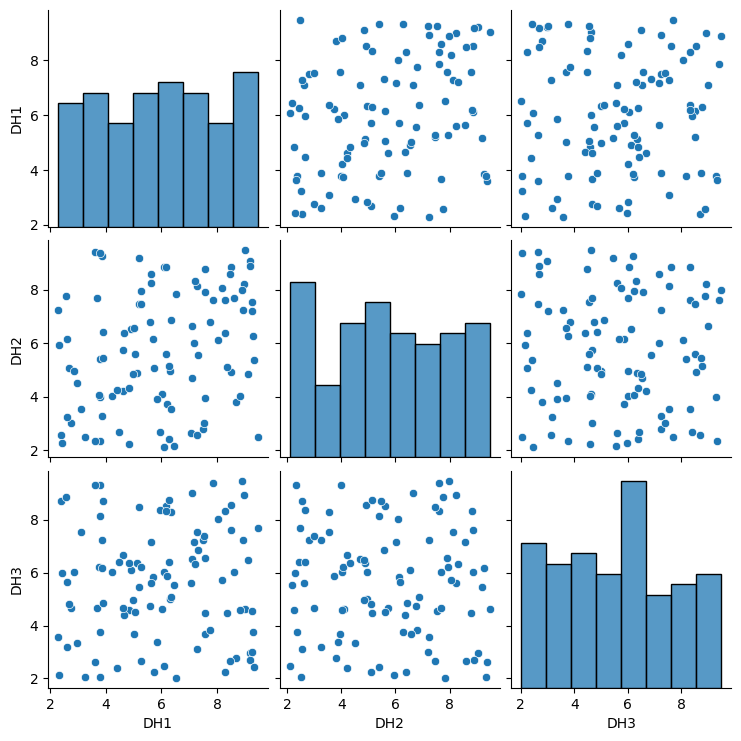

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 0. Load dữ liệu
df = pd.read_csv('processed_dulieuxettuyendaihoc.csv')

# --- BƯỚC CHUẨN BỊ: Tạo cột Ketqua (nếu file chưa có) ---
# Giả sử Đậu là tổng DH1+DH2+DH3 >= 15 (Bạn có thể sửa lại ngưỡng này)
df['Ketqua'] = np.where((df['DH1'] + df['DH2'] + df['DH3']) >= 15, 'Dau', 'Rot')

# --- PHẦN 1: THỐNG KÊ ---
print("--- PHẦN 1 ---")
print(df['DH1'].sort_values().head())
pt = df.pivot_table(index=['KT', 'KV', 'DT'], values='DH1', 
                    aggfunc=['count', 'sum', 'mean', 'median', 'min', 'max', 'std'])
print(pt)

# --- PHẦN 2 & 3: TRÌNH BÀY & TRỰC QUAN HÓA NHÓM ---
print("\n--- PHẦN 2 & 3 ---")
df['GT'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Biểu đồ GT')
plt.show()

sns.countplot(x='KV', hue='Ketqua', data=df)
plt.title('Biểu đồ Đậu/Rớt theo KV')
plt.show()

# --- PHẦN 4: TRỰC QUAN HÓA NÂNG CAO ---
print("\n--- PHẦN 4 ---")
def phanloai_t1(diem):
    if diem < 5: return 'Kem'
    elif diem < 7: return 'Trungbinh'
    elif diem < 8: return 'Kha'
    else: return 'Gioi'

df['phanlopt1'] = df['T1'].apply(phanloai_t1)
df['phanlopt1'] = pd.Categorical(df['phanlopt1'], categories=['Kem', 'Trungbinh', 'Kha', 'Gioi'], ordered=True)

# Multiple Line
df_grouped = df.groupby(['phanlopt1', 'T1']).size().reset_index(name='Count')
sns.lineplot(data=df_grouped, x='T1', y='Count', hue='phanlopt1', marker='o')
plt.title('Multiple Line: T1 theo phanlopt1')
plt.show()

# --- PHẦN 5: KHẢO SÁT PHÂN PHỐI & TƯƠNG QUAN ---
print("\n--- PHẦN 5 ---")
# Boxplot & Histogram
sns.histplot(df['T1'], kde=True)
plt.show()
sns.boxplot(x=df['T1'])
plt.show()

# QQ-Plot
sm.qqplot(df['T1'], line='s')
plt.title('QQ-Plot cho T1')
plt.show()

# Tương quan
corr = df[['DH1', 'DH2', 'DH3']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()
sns.pairplot(df[['DH1', 'DH2', 'DH3']])
plt.show()